In [160]:
import mlflow
mlflow.set_experiment("mlops-learn1")
mlflow.sklearn.autolog()
if mlflow.active_run() is not None:
    mlflow.end_run()

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [126]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [127]:
import xgboost as xgb
import shap

In [128]:
!ls data/

matchStats.csv	playerStats.csv  teamStats.csv


In [129]:
matchStats = pd.read_csv("data/matchStats.csv")
playerStats = pd.read_csv("data/playerStats.csv")
teamStats = pd.read_csv("data/teamStats.csv")

In [130]:
matchStats.head()

,Date,Home Team,Away Team,Winner,Loser,Kills Home,Kills Away,Blocks Home,Blocks Away,Aces Home,...,Set1 Home,Set1 Away,Set2 Home,Set2 Away,Set3 Home,Set3 Away,Set4 Home,Set4 Away,Set5 Home,Set5 Away
0,2025-08-02,Italy,Slovenia,Italy,Slovenia,62,52,10,9,9,...,25,22,22,25,25,21,25.0,18.0,NaN,NaN
1,2025-08-02,Brazil,Poland,Poland,Brazil,32,41,7,6,6,...,26,28,19,25,21,25,NaN,NaN,NaN,NaN
2,2025-08-03,Brazil,Slovenia,Brazil,Slovenia,48,49,11,7,5,...,23,25,25,20,25,23,25.0,19.0,NaN,NaN
3,2025-08-03,Poland,Italy,Poland,Italy,37,27,10,6,3,...,25,22,25,19,25,14,NaN,NaN,NaN,NaN
4,2025-07-30,Italy,Cuba,Italy,Cuba,42,55,9,6,7,...,25,18,25,19,20,25,25.0,21.0,NaN,NaN


In [131]:
matchStats.columns

Index(['Date', 'Home Team', 'Away Team', 'Winner', 'Loser', 'Kills Home',
       'Kills Away', 'Blocks Home', 'Blocks Away', 'Aces Home', 'Aces Away',
       'Opponents Errors Home', 'Opponents Errors Away', 'Total Points Home',
       'Total Points Away', 'Digs Home', 'Digs Away', 'Receptions Home',
       'Receptions Away', 'Sets Home', 'Sets Away', 'Set1 Home', 'Set1 Away',
       'Set2 Home', 'Set2 Away', 'Set3 Home', 'Set3 Away', 'Set4 Home',
       'Set4 Away', 'Set5 Home', 'Set5 Away'],
      dtype='object')

In [132]:
playerStats.head()

,Player Name,Team,Position,Age,Height,Running Sets,Setting Errors,Still Sets,Sets Per Match,Successful Receives,...,Rebounds,Blocks Per Match,Great Saves,Defensive Errors,Defensive Receptions,Digs Per Match,Kills,Attacking Errors,Attacking Attempts,Attacks Per Match
0,A. Lagumdzija,TUR,OPPOSITE SPIKER,26,211cm,1,0,4,0.25,1,...,11,1.00,25,14,5,6.25,60,18,65,15.00
1,A. Nikolov,BUL,OUTSIDE HITTER,21,207cm,6,1,36,0.50,46,...,22,1.25,61,17,31,5.08,177,54,124,14.75
2,Adamczyk,POL,MIDDLE BLOCKER,26,208cm,0,0,3,0.00,0,...,4,0.75,2,4,4,0.50,11,1,8,2.75
3,Adriano,BRA,OUTSIDE HITTER,23,201cm,0,0,9,0.00,9,...,5,0.07,9,6,4,0.60,12,10,21,0.80
4,Ahyi,NED,OPPOSITE SPIKER,27,200cm,2,0,22,0.17,0,...,22,1.17,33,36,29,2.75,161,53,115,13.42


In [133]:
playerStats.columns

Index(['Player Name', 'Team', 'Position', 'Age', 'Height', 'Running Sets',
       'Setting Errors', 'Still Sets', 'Sets Per Match', 'Successful Receives',
       'Receiving Errors', 'Service Receptions', 'Receives Per Match', 'Aces',
       'Service Errors', 'Service Attempts', 'Serves Per Match', 'Blocks',
       'Blocking Errors', 'Rebounds', 'Blocks Per Match', 'Great Saves',
       'Defensive Errors', 'Defensive Receptions', 'Digs Per Match', 'Kills',
       'Attacking Errors', 'Attacking Attempts', 'Attacks Per Match'],
      dtype='object')

In [134]:
teamStats.head()

,Rank,Team,Total,Won,Lost,3-0,3-1,3-2,2-3,1-3,0-3,Points,Sets Won,Sets Lost,Set Ratio,Points Won,Points Lost,Point Ratio
0,1,Brazil,12,11,1,5,4,2,1,0,0,32,35,11,3.181,1095,998,1.097
1,2,Italy,12,10,2,5,2,3,1,1,0,28,33,14,2.357,1100,962,1.143
2,3,France,12,8,4,4,2,2,2,2,0,24,30,18,1.666,1124,1050,1.070
3,4,Japan,12,8,4,5,1,2,1,1,2,23,27,17,1.588,1036,977,1.060
4,5,Poland,12,8,4,3,2,3,2,2,0,23,30,20,1.500,1157,1129,1.024


In [135]:
teamStats.columns

Index(['Rank', 'Team', 'Total', 'Won', 'Lost', '3-0', '3-1', '3-2', '2-3',
       '1-3', '0-3', 'Points', 'Sets Won', 'Sets Lost', 'Set Ratio',
       'Points Won', 'Points Lost', 'Point Ratio'],
      dtype='object')

We will do a model that can predict the position of a player based on the stats.
###### (Should be straightforward...)

In [136]:
playerStats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339 entries, 0 to 338
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Player Name           339 non-null    object 
 1   Team                  339 non-null    object 
 2   Position              339 non-null    object 
 3   Age                   339 non-null    int64  
 4   Height                339 non-null    object 
 5   Running Sets          339 non-null    int64  
 6   Setting Errors        339 non-null    int64  
 7   Still Sets            339 non-null    int64  
 8   Sets Per Match        339 non-null    float64
 9   Successful Receives   339 non-null    int64  
 10  Receiving Errors      339 non-null    int64  
 11  Service Receptions    339 non-null    int64  
 12  Receives Per Match    339 non-null    float64
 13  Aces                  339 non-null    int64  
 14  Service Errors        339 non-null    int64  
 15  Service Attempts      3

In [137]:
# playerStats.describe()
playerStats.isnull().sum()
# playerStats.dropna(inplace=True)


Player Name             0
Team                    0
Position                0
Age                     0
Height                  0
Running Sets            0
Setting Errors          0
Still Sets              0
Sets Per Match          0
Successful Receives     0
Receiving Errors        0
Service Receptions      0
Receives Per Match      0
Aces                    0
Service Errors          0
Service Attempts        0
Serves Per Match        0
Blocks                  0
Blocking Errors         0
Rebounds                0
Blocks Per Match        0
Great Saves             0
Defensive Errors        0
Defensive Receptions    0
Digs Per Match          0
Kills                   0
Attacking Errors        0
Attacking Attempts      0
Attacks Per Match       0
dtype: int64

# Feature Selection:

1. Remove unnecessary columns
2. Remove Highly Correlated features
3. Do scaling
4. Feature selection using XGBoost

In [138]:
playerStats.drop(columns=["Player Name", "Team"],inplace=True)

In [139]:
playerStats.columns

Index(['Position', 'Age', 'Height', 'Running Sets', 'Setting Errors',
       'Still Sets', 'Sets Per Match', 'Successful Receives',
       'Receiving Errors', 'Service Receptions', 'Receives Per Match', 'Aces',
       'Service Errors', 'Service Attempts', 'Serves Per Match', 'Blocks',
       'Blocking Errors', 'Rebounds', 'Blocks Per Match', 'Great Saves',
       'Defensive Errors', 'Defensive Receptions', 'Digs Per Match', 'Kills',
       'Attacking Errors', 'Attacking Attempts', 'Attacks Per Match'],
      dtype='object')

In [140]:
X=playerStats.drop(columns=["Position"])
y=playerStats["Position"]


In [141]:
X

,Age,Height,Running Sets,Setting Errors,Still Sets,Sets Per Match,Successful Receives,Receiving Errors,Service Receptions,Receives Per Match,...,Rebounds,Blocks Per Match,Great Saves,Defensive Errors,Defensive Receptions,Digs Per Match,Kills,Attacking Errors,Attacking Attempts,Attacks Per Match
0,26,211cm,1,0,4,0.25,1,1,2,0.25,...,11,1.00,25,14,5,6.25,60,18,65,15.00
1,21,207cm,6,1,36,0.50,46,19,191,3.83,...,22,1.25,61,17,31,5.08,177,54,124,14.75
2,26,208cm,0,0,3,0.00,0,0,1,0.00,...,4,0.75,2,4,4,0.50,11,1,8,2.75
3,23,201cm,0,0,9,0.00,9,2,38,0.60,...,5,0.07,9,6,4,0.60,12,10,21,0.80
4,27,200cm,2,0,22,0.17,0,0,2,0.00,...,22,1.17,33,36,29,2.75,161,53,115,13.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334,32,190cm,230,0,547,19.17,0,1,3,0.00,...,40,0.58,47,35,26,3.92,5,0,4,0.42
335,20,190cm,0,0,1,0.00,1,0,2,0.25,...,1,0.00,0,0,2,0.00,1,1,1,0.25
336,30,196cm,0,0,7,0.00,8,4,14,2.00,...,3,0.25,5,4,8,1.25,16,6,13,4.00
337,23,192cm,0,0,2,0.00,3,3,6,0.30,...,0,0.00,1,0,3,0.10,2,1,8,0.20


In [142]:
y

0      OPPOSITE SPIKER
1       OUTSIDE HITTER
2       MIDDLE BLOCKER
3       OUTSIDE HITTER
4      OPPOSITE SPIKER
            ...       
334             SETTER
335     OUTSIDE HITTER
336     OUTSIDE HITTER
337     OUTSIDE HITTER
338     MIDDLE BLOCKER
Name: Position, Length: 339, dtype: object

In [143]:
y.unique()

array(['OPPOSITE SPIKER', 'OUTSIDE HITTER', 'MIDDLE BLOCKER', 'LIBERO',
       'SETTER'], dtype=object)

In [144]:
# -------------------------------------------------
# 1️⃣ Select numeric columns
# -------------------------------------------------
numeric_cols = X.select_dtypes(include='number').columns
numeric_data = X[numeric_cols]

# -------------------------------------------------
# 2️⃣ Compute correlation matrix
# -------------------------------------------------
corr_matrix = numeric_data.corr()
print(corr_matrix)

# -------------------------------------------------
# 3️⃣ Define correlation threshold
#     - Here we flag correlations > 0.8
# -------------------------------------------------
threshold = 0.8

# -------------------------------------------------
# 4️⃣ Find pairs of highly correlated features
# -------------------------------------------------
high_corr = (corr_matrix.abs() > threshold) & (corr_matrix.abs() < 1)

# Collect pairs in a list
high_corr_pairs = [
    (col1, col2, corr_matrix.loc[col1, col2])
    for col1 in corr_matrix.columns
    for col2 in corr_matrix.columns
    if high_corr.loc[col1, col2]
]

# -------------------------------------------------
# 5️⃣ Print highly correlated feature pairs
# -------------------------------------------------
print("Highly correlated pairs (> 0.8):")
for pair in high_corr_pairs:
    print(pair)

                           Age  Running Sets  Setting Errors  Still Sets  \
Age                   1.000000      0.121945        0.118029    0.121434   
Running Sets          0.121945      1.000000        0.644577    0.964907   
Setting Errors        0.118029      0.644577        1.000000    0.633288   
Still Sets            0.121434      0.964907        0.633288    1.000000   
Sets Per Match        0.129865      0.976958        0.627634    0.943194   
Successful Receives   0.001462     -0.169044       -0.005701   -0.070222   
Receiving Errors     -0.026257     -0.162286        0.011919   -0.076452   
Service Receptions   -0.030892     -0.172702        0.000462   -0.079684   
Receives Per Match    0.039151     -0.181284       -0.031154   -0.088941   
Aces                  0.001800      0.106898        0.103108    0.117875   
Service Errors       -0.030198      0.096673        0.095853    0.125286   
Service Attempts      0.147208      0.313007        0.255407    0.333982   
Serves Per M

Too many highly correlated columns... we take the columns that best represent each stats

In [145]:
# -------------------------------------------------
# Drop selected features from merged_data
# -------------------------------------------------
X = X[["Age","Sets Per Match", "Receives Per Match", "Serves Per Match", "Blocks Per Match", "Digs Per Match", "Attacks Per Match"]]

# -------------------------------------------------
# Print remaining columns for verification
# -------------------------------------------------
print(X.columns)

Index(['Age', 'Sets Per Match', 'Receives Per Match', 'Serves Per Match',
       'Blocks Per Match', 'Digs Per Match', 'Attacks Per Match'],
      dtype='object')


In [146]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

In [147]:
print(le.classes_)  

['LIBERO' 'MIDDLE BLOCKER' 'OPPOSITE SPIKER' 'OUTSIDE HITTER' 'SETTER']


In [148]:
y_encoded

array([2, 3, 1, 3, 2, 2, 0, 1, 2, 2, 1, 2, 0, 3, 4, 3, 3, 3, 0, 3, 0, 3,
       1, 3, 4, 2, 0, 4, 3, 2, 0, 2, 3, 3, 3, 0, 4, 4, 2, 0, 2, 1, 2, 3,
       4, 3, 1, 1, 2, 3, 1, 3, 1, 0, 0, 2, 0, 0, 0, 3, 2, 3, 0, 2, 3, 0,
       4, 1, 4, 2, 1, 3, 3, 2, 2, 4, 1, 4, 1, 3, 3, 1, 1, 1, 0, 2, 1, 1,
       1, 4, 3, 4, 2, 4, 2, 2, 3, 0, 0, 0, 4, 1, 2, 1, 3, 1, 2, 3, 0, 0,
       0, 3, 4, 3, 4, 2, 3, 1, 0, 1, 1, 4, 3, 0, 3, 3, 1, 4, 1, 3, 2, 2,
       4, 1, 3, 3, 4, 2, 3, 3, 0, 1, 1, 1, 4, 3, 1, 1, 1, 3, 0, 1, 4, 1,
       1, 1, 2, 2, 1, 3, 1, 0, 3, 1, 3, 0, 1, 2, 0, 3, 1, 3, 2, 3, 3, 0,
       3, 4, 1, 1, 1, 3, 0, 3, 3, 1, 0, 3, 2, 1, 4, 1, 1, 1, 3, 1, 1, 3,
       2, 3, 1, 3, 4, 1, 2, 1, 0, 3, 3, 4, 2, 1, 1, 4, 3, 2, 1, 0, 2, 1,
       2, 1, 0, 0, 1, 3, 4, 0, 1, 4, 3, 0, 1, 3, 2, 1, 3, 3, 1, 1, 1, 1,
       1, 4, 3, 0, 3, 3, 1, 3, 0, 0, 3, 1, 3, 0, 3, 2, 4, 2, 3, 4, 2, 2,
       1, 4, 1, 3, 2, 1, 1, 4, 0, 1, 2, 3, 1, 4, 4, 0, 1, 0, 1, 3, 4, 3,
       3, 2, 3, 4, 2, 1, 1, 4, 4, 4, 4, 1, 3, 4, 1,

2026/02/27 01:14:20 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/nas/Projects/mlopslearn/venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/02/27 01:14:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


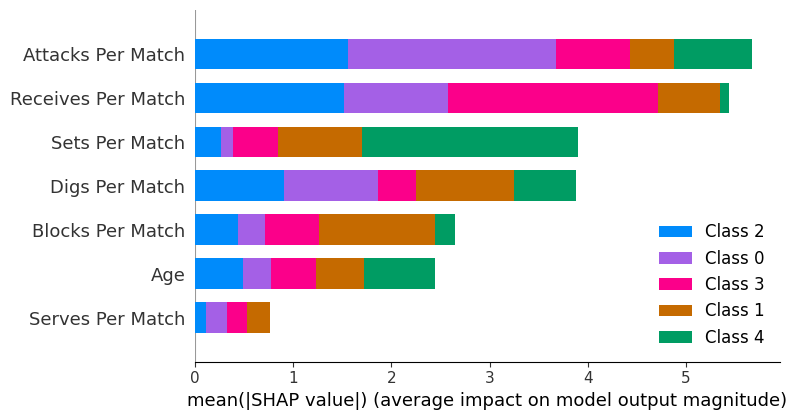

In [149]:
# Model
with mlflow.start_run():
    model_feature_selection = xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=5,
        eval_metric='mlogloss'
    )
    mlflow.set_tag("run_type", "feature_selection")

    model_feature_selection.fit(X, y_encoded)
    explainer = shap.TreeExplainer(model_feature_selection)
    shap_values = explainer.shap_values(X)

    # Summary plot of SHAP values (shows global feature impact)
    shap.summary_plot(shap_values, X, plot_type="bar")

Lets drop Serves Per Match and Age

In [150]:
X = X.drop(columns=["Age", "Serves Per Match"])

# Split for training & test

In [151]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [152]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

In [153]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(271, 5) (271,)
(68, 5) (68,)


Training multiple models:

1. Logistic Regression
2. Random Forest
3. SVM
4. XGBoost

In [154]:
logistic = LogisticRegression(solver="lbfgs", max_iter=1000, random_state=42)
random_forest = RandomForestClassifier(n_estimators=200, random_state=42)
svm = SVC( kernel="rbf", probability=True, decision_function_shape="ovr", random_state=42)
xgboost = xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=len(le.classes_),
        eval_metric="mlogloss",
        random_state=42)

In [155]:
with mlflow.start_run():
    logistic.fit(X_train,y_train)
    mlflow.set_tag("run_type", "logistic")
    y_pred = logistic.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc}")
    print(f"Classification Report: {classification_report(y_test, y_pred, target_names=le.classes_)}")

2026/02/27 01:14:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.8382352941176471
Classification Report:                  precision    recall  f1-score   support

         LIBERO       1.00      0.64      0.78        11
 MIDDLE BLOCKER       0.80      0.89      0.84        18
OPPOSITE SPIKER       0.80      0.80      0.80        10
 OUTSIDE HITTER       0.78      0.86      0.82        21
         SETTER       1.00      1.00      1.00         8

       accuracy                           0.84        68
      macro avg       0.88      0.84      0.85        68
   weighted avg       0.85      0.84      0.84        68



In [156]:
with mlflow.start_run():
    random_forest.fit(X_train,y_train)
    mlflow.set_tag("run_type", "random_forest")
    y_pred = random_forest.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc}")
    print(f"Classification Report: {classification_report(y_test, y_pred, target_names=le.classes_)}")

2026/02/27 01:14:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.8529411764705882
Classification Report:                  precision    recall  f1-score   support

         LIBERO       1.00      0.91      0.95        11
 MIDDLE BLOCKER       0.75      0.83      0.79        18
OPPOSITE SPIKER       0.70      0.70      0.70        10
 OUTSIDE HITTER       0.90      0.86      0.88        21
         SETTER       1.00      1.00      1.00         8

       accuracy                           0.85        68
      macro avg       0.87      0.86      0.86        68
   weighted avg       0.86      0.85      0.85        68



In [157]:
with mlflow.start_run():
    svm.fit(X_train,y_train)
    mlflow.set_tag("run_type", "svm")
    y_pred = svm.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc}")
    print(f"Classification Report: {classification_report(y_test, y_pred, target_names=le.classes_)}")

2026/02/27 01:14:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.8088235294117647
Classification Report:                  precision    recall  f1-score   support

         LIBERO       1.00      0.55      0.71        11
 MIDDLE BLOCKER       0.71      0.94      0.81        18
OPPOSITE SPIKER       0.88      0.70      0.78        10
 OUTSIDE HITTER       0.77      0.81      0.79        21
         SETTER       1.00      1.00      1.00         8

       accuracy                           0.81        68
      macro avg       0.87      0.80      0.82        68
   weighted avg       0.83      0.81      0.80        68



In [161]:
with mlflow.start_run():
    xgboost.fit(X_train,y_train)
    mlflow.set_tag("run_type", "xgboost")
    y_pred = xgboost.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc}")
    print(f"Classification Report: {classification_report(y_test, y_pred, target_names=le.classes_)}")

2026/02/27 01:26:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy: 0.8382352941176471
Classification Report:                  precision    recall  f1-score   support

         LIBERO       1.00      0.82      0.90        11
 MIDDLE BLOCKER       0.74      0.78      0.76        18
OPPOSITE SPIKER       0.73      0.80      0.76        10
 OUTSIDE HITTER       0.86      0.86      0.86        21
         SETTER       1.00      1.00      1.00         8

       accuracy                           0.84        68
      macro avg       0.86      0.85      0.86        68
   weighted avg       0.85      0.84      0.84        68

